# 9. Probability calibration

**Question: do the predicted probabilities mean what they say — and does it matter?**

A model can rank trucks perfectly and still be badly calibrated: if it says "0.9" for
cases that fail 40% of the time, the ranking is fine but the number is a lie.

Two reasons that matters here:

1. The Bayes threshold from [notebook 02](02_cost_sensitive_baselines.ipynb) is only
   valid for calibrated probabilities. Applying `0.0196` to uncalibrated scores has no
   theoretical basis.
2. Anyone consuming the model's output as a risk estimate — a maintenance planner
   deciding how to sequence a queue — is relying on the number, not the rank.

Calibration is fitted on a **dedicated subset** that is used for nothing else. Reusing the
tuning data would fit the correction to points the model has already been optimised
against, which flatters the result.

> **The objective.** Every number in this notebook is judged against
> `J = 10·FP + 500·FN`. A false positive is an unnecessary inspection; a false
> negative is a truck that fails in service. Missing one failure costs as much
> as fifty needless inspections, and that ratio is what makes the modelling
> choices here matter.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from scania_aps.data import TEST_FILENAME, TRAIN_FILENAME, read_raw_csv
from scania_aps.plotting import apply_house_style

ROOT = Path.cwd().resolve()
if ROOT.name == "experiments":
    ROOT = ROOT.parent
TRAIN = ROOT / "data" / "raw" / TRAIN_FILENAME
TEST = ROOT / "data" / "raw" / TEST_FILENAME
ARTIFACTS = ROOT / "artifacts"
assert TRAIN.exists() and TEST.exists(), "Run: poetry run scania-aps download"

apply_house_style()

train = read_raw_csv(TRAIN)
test = read_raw_csv(TEST)

pd.DataFrame(
    {
        "trucks": [len(train.y), len(test.y)],
        "features": [train.X.shape[1], test.X.shape[1]],
        "failures": [int(train.y.sum()), int(test.y.sum())],
        "failure_rate": [train.y.mean(), test.y.mean()],
    },
    index=["training set", "official test set"],
)

,trucks,features,failures,failure_rate
training set,60000,170,1000,0.016667
official test set,16000,170,375,0.023438


In [2]:
from scania_aps.studies import run_calibration_study

calibration = run_calibration_study(TRAIN, TEST, ARTIFACTS, family="xgboost", profile="full")
calibration

,family,calibration,threshold,total_cost,cost_per_observation,false_positives,false_negatives,precision,recall,pr_auc,roc_auc,always_negative_cost,always_positive_cost,saving_vs_always_negative,saving_vs_always_positive,score_kind,brier,log_loss
0,xgboost,none,0.019734,10870.0,0.679375,487,12,0.427059,0.968000,0.924416,0.995102,187500.0,156250.0,176630.0,145380.0,probability,0.005819,0.021659
1,xgboost,sigmoid,0.001237,10870.0,0.679375,487,12,0.427059,0.968000,0.924416,0.995102,187500.0,156250.0,176630.0,145380.0,probability,0.005248,0.025923
2,xgboost,isotonic,0.002076,12620.0,0.788750,1012,5,0.267728,0.986667,0.896399,0.993566,187500.0,156250.0,174880.0,143630.0,probability,0.005041,0.024463


## Reliability

The diagonal is perfect calibration. A curve below it means the model is overconfident —
it predicts higher risk than actually materialises; above means underconfident.

Because failures are rare, most predictions cluster near zero. The bins are therefore
taken on the model's own quantiles rather than on an even grid, or almost every point
would land in the first bin.

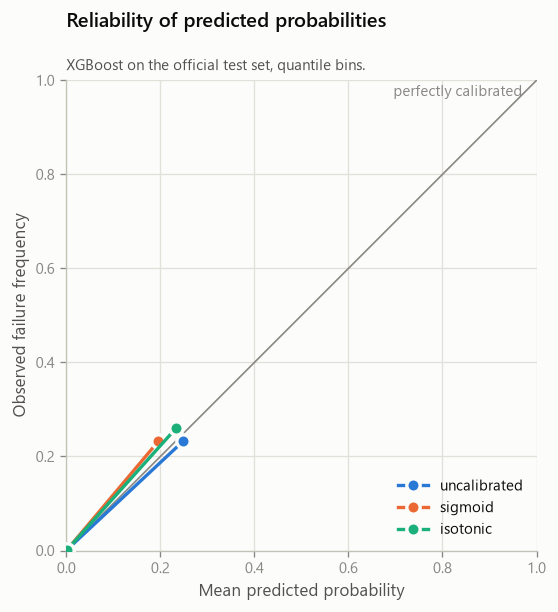

In [3]:
from sklearn.calibration import calibration_curve

from scania_aps.calibration import calibrate_prefit_model
from scania_aps.model_search import candidates_for_family
from scania_aps.models.factory import build_candidate
from scania_aps.plotting import reliability_diagram
from scania_aps.scoring import positive_class_scores
from scania_aps.split import research_split

split = research_split(train.X, train.y)
candidate = candidates_for_family("xgboost", profile="quick")[0]

base = build_candidate(candidate)
base.fit(pd.concat([split.X_fit, split.X_tune]), pd.concat([split.y_fit, split.y_tune]))

curves = {}
probabilities = {}
for method in (None, "sigmoid", "isotonic"):
    model = (
        base
        if method is None
        else calibrate_prefit_model(base, split.X_calibration, split.y_calibration, method=method)
    )
    p = positive_class_scores(model, test.X).values
    probabilities["uncalibrated" if method is None else method] = p
    observed, predicted = calibration_curve(test.y.to_numpy(), p, n_bins=10, strategy="quantile")
    curves["uncalibrated" if method is None else method] = (predicted, observed)

fig, ax = reliability_diagram(
    curves,
    subtitle="XGBoost on the official test set, quantile bins.",
)

## Proper scoring rules

Brier score and log loss both reward calibration; PR-AUC sees only the ranking. Reading
the three together separates "the probabilities improved" from "the ordering changed",
which is the distinction that matters when deciding whether a correction was worth
applying.

In [4]:
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss

scores = pd.DataFrame(
    [
        {
            "method": name,
            "brier": brier_score_loss(test.y.to_numpy(), p),
            "log_loss": log_loss(test.y.to_numpy(), np.clip(p, 1e-15, 1 - 1e-15)),
            "pr_auc": average_precision_score(test.y.to_numpy(), p),
        }
        for name, p in probabilities.items()
    ]
).set_index("method")
scores

,brier,log_loss,pr_auc
method,,,
uncalibrated,0.005251,0.020241,0.922788
sigmoid,0.005290,0.026402,0.922788
isotonic,0.005302,0.026653,0.885766


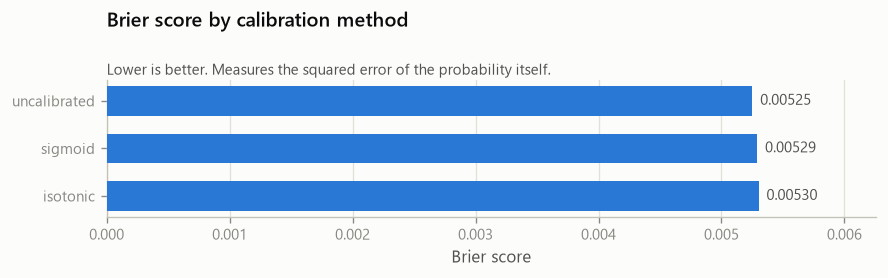

In [5]:
from scania_aps.plotting import magnitude_bars

fig, ax = magnitude_bars(
    list(scores.index),
    [float(v) for v in scores["brier"].to_numpy()],
    title="Brier score by calibration method",
    subtitle="Lower is better. Measures the squared error of the probability itself.",
    xlabel="Brier score",
    value_format="{:.5f}",
)

### Reading the result

**Neither correction improved the probabilities.** Brier score and log loss are both
lowest for the uncalibrated model, and the calibrated variants are worse on the metrics
specifically designed to reward calibration.

That is a real finding, not a failure of the experiment, and it has a clear cause. Gradient
boosting with log loss is already close to calibrated on this data — the reliability
curve above does not stray far from the diagonal. Fitting a correction to a model that
does not need one adds variance: the correction is estimated from a limited calibration
subset, and that estimation error is what shows up as a slightly worse score.

Two more specific things to notice:

**Sigmoid leaves PR-AUC untouched; isotonic does not.** Platt scaling is a strictly
monotone function, so it cannot change the ordering of any pair of trucks — the ranking
metric is identical to the fourth decimal. Isotonic regression is monotone but only
*non-decreasing*: it is a step function, and it maps whole ranges of scores onto a single
value. Those ties collapse the ordering inside each step, which is exactly what the drop
in PR-AUC is measuring. Isotonic is the more flexible correction and, on a rare-event
problem where the positives are thinly spread, that flexibility costs ranking
information.

**Calibration and thresholding are partly redundant.** A monotone transform followed by a
re-optimised threshold can flag exactly the same set of trucks as no transform at all
with its own re-optimised threshold. Where calibration earns its place is when the
*number itself* is consumed — when a planner reads "3% chance of failure" and sequences a
queue by it, or when the theoretical `0.0196` is used instead of a fitted threshold, as
in [notebook 10](10_threshold_optimization.ipynb).

On this model, the honest recommendation is to skip the correction and use the raw
scores.

**Next:** [10 — threshold optimization](10_threshold_optimization.ipynb), where the
decision rule is finally isolated.